In [1]:
import sys
from pathlib import Path

sys.path.insert(0, "/kaggle/input/datasets/gpla77/project4-code")

import torch
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# Kaggle:
ARMADILLO_PATH = Path("/kaggle/input/datasets/gpla77/pro4-data/modele/armadillo_small.obj")
TEAPOT_PATH    = Path("/kaggle/input/datasets/gpla77/pro4-data/modele/teapot.obj")
CKPT_DIR       = Path("/kaggle/working/checkpoints")

# Local:
# ARMADILLO_PATH = Path("../modele/armadillo_small.obj")
# TEAPOT_PATH    = Path("../modele/teapot.obj")
# CKPT_DIR       = Path("checkpoints")

CKPT_DIR.mkdir(parents=True, exist_ok=True)

print(f"Device    : {DEVICE}")
if DEVICE == "cuda":
    print(f"GPU       : {torch.cuda.get_device_name(0)}")
print(f"Armadillo : {ARMADILLO_PATH}  (exists: {ARMADILLO_PATH.exists()})")
print(f"Teapot    : {TEAPOT_PATH}     (exists: {TEAPOT_PATH.exists()})")

Device    : cuda
GPU       : Tesla T4
Armadillo : /kaggle/input/datasets/gpla77/pro4-data/modele/armadillo_small.obj  (exists: True)
Teapot    : /kaggle/input/datasets/gpla77/pro4-data/modele/teapot.obj     (exists: True)


In [2]:
from dataset import ArmadilloTeapotDataset

dataset = ArmadilloTeapotDataset(
    armadillo_path = str(ARMADILLO_PATH),
    teapot_path    = str(TEAPOT_PATH),
    n_points       = 2048,
    n_samples      = 10000,
    augment        = True,
)

src, tgt = dataset[0]
print(f"Train samples : {len(dataset)}")
print(f"Source shape  : {src.shape}")
print(f"Target shape  : {tgt.shape}")

Train samples : 10000
Source shape  : torch.Size([2048, 3])
Target shape  : torch.Size([2048, 3])


VectorFieldNet  params: 373,251


Epoch 001/3:   0%|          | 0/563 [00:00<?, ?batch/s]

Epoch 001/3  loss=0.021139  lr=1.00e-03
  └─ val  loss=0.006331  (best=0.006331)  [saved]


Epoch 002/3:   0%|          | 0/563 [00:00<?, ?batch/s]

Epoch 002/3  loss=0.005338  lr=7.50e-04
  └─ val  loss=0.004183  (best=0.004183)  [saved]


Epoch 003/3:   0%|          | 0/563 [00:00<?, ?batch/s]

Epoch 003/3  loss=0.004056  lr=2.51e-04
  └─ val  loss=0.003596  (best=0.003596)  [saved]


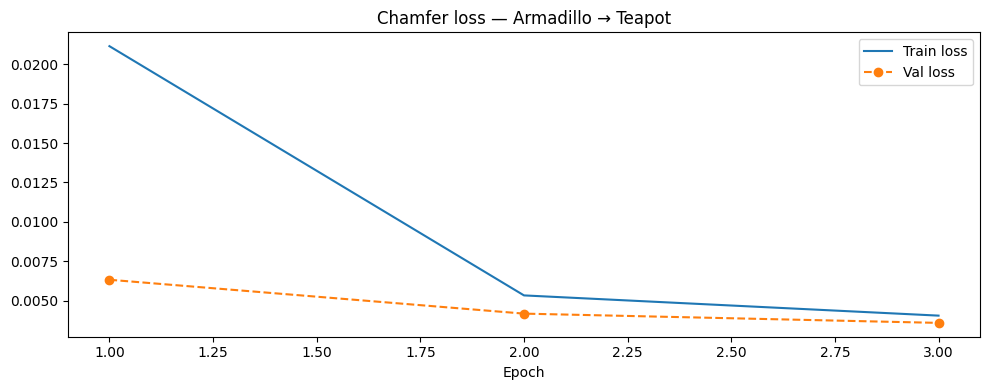


Done. Best val loss: 0.003596 → /kaggle/working/checkpoints/best_model.pt


In [3]:
from train import train

model = train(
    armadillo_path     = str(ARMADILLO_PATH),
    teapot_path        = str(TEAPOT_PATH),
    n_points           = 2048,
    n_samples          = 10000,
    augment            = True,
    local_hidden_dims  = [64, 128],
    global_hidden_dims = [256, 512],
    output_hidden_dims = [256, 128],
    dropout            = 0.0,
    epochs             = 3,
    batch_size         = 16,
    lr                 = 1e-3,
    optimizer          = "adam",
    scheduler          = "cosine",
    save_every         = 1,
    device             = DEVICE,
    ckpt_dir           = str(CKPT_DIR),
)